In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Dataset.csv")# i am loading the data here(date: 4 th feb)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features = ['distance_error_cm', 'velocity_error_cmps', 'actual_velocity_cmps', 'target_velocity_cmps']
X = df[features]
y = df['pwm_output']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # scaled value=(value-mean)/standard deviation
X_test_scaled = scaler.transform(X_test)
print("Feature Means:", scaler.mean_)
print("Feature STDs:", scaler.scale_)

Feature Means: [115.64379085   0.98366013  29.0245098   30.        ]
Feature STDs: [80.22929096  2.47927244  2.47821632  1.        ]


###After StandardScaler transforms data becomes:
1.No single feature dominates just because it has larger numbers

2.The network learns weights more efficiently



In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='linear')
])
model.summary()
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1627.2169 - mae: 35.1806 - val_loss: 1729.5427 - val_mae: 37.2424
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1855.2175 - mae: 35.7815 - val_loss: 1689.5536 - val_mae: 36.8912
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1528.4506 - mae: 33.3325 - val_loss: 1630.4062 - val_mae: 36.3599
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1536.5114 - mae: 34.2917 - val_loss: 1546.8179 - val_mae: 35.5770
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1487.4458 - mae: 32.4545 - val_loss: 1437.7588 - val_mae: 34.4934
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1379.0453 - mae: 31.9664 - val_loss: 1301.4827 - val_mae: 33.0610
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1247.6555 - mae: 31.4357 - val_loss: 1142.8541 - val_mae: 31.2524
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1097.6777 - mae: 29.4135 - val_loss: 963.1207 - val_mae: 28.9902
Epoch 9/

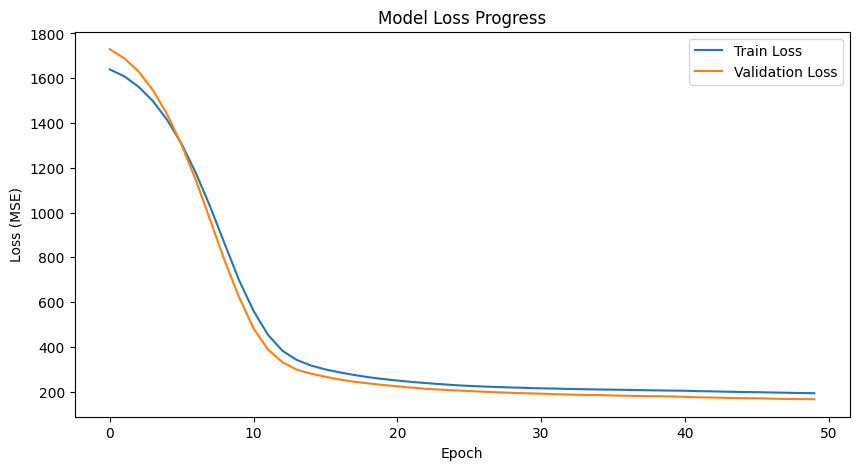

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


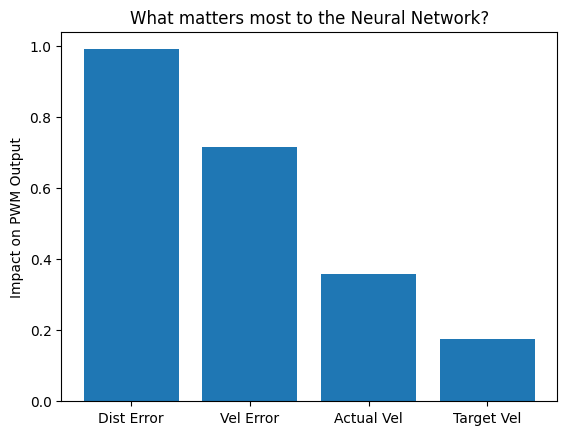

In [6]:
import matplotlib.pyplot as plt
import numpy as np
def get_feature_importance(model, base_input):
    base_pred = model.predict(base_input)
    importances = []
    for i in range(4):
        temp_input = base_input.copy()
        temp_input[0][i] += 0.1
        new_pred = model.predict(temp_input)
        change = np.abs(new_pred - base_pred)
        importances.append(change[0][0])
    return importances
sample_idx = 0
sample_input = X_test_scaled[sample_idx].reshape(1, 4)
scores = get_feature_importance(model, sample_input)
features = ['Dist Error', 'Vel Error', 'Actual Vel', 'Target Vel']
plt.bar(features, scores)
plt.title("What matters most to the Neural Network?")
plt.ylabel("Impact on PWM Output")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
R² Score: 0.5262
MSE: 192.5877


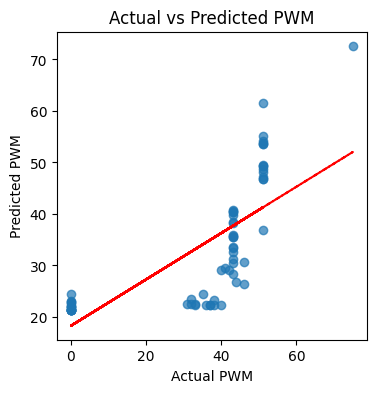

In [7]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred, alpha=0.7)

a, b = np.polyfit(y_test, y_pred, 1)
y_fit = a * y_test + b
plt.plot(y_test, y_fit, color='red', linestyle='--', label='Best-Fit Line')

plt.xlabel("Actual PWM")
plt.ylabel("Predicted PWM")
plt.title("Actual vs Predicted PWM")
plt.show()


In [8]:
model.save("model.keras")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
open("tensor.tflite", "wb").write(tflite_model)

Saved artifact at '/tmp/tmpl4xyahbx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140422437243792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140422437244944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140422437243600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140422437241488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140422437245520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140422437242448: TensorSpec(shape=(), dtype=tf.resource, name=None)


2800